# Network Traffic DWH Preparation
### CICIDS2017 + UNSW-NB15 Integration Pipeline


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#378ADD']
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Raw Data

To scale to all 8 CICIDS files + 3 UNSW files, just extend the lists below.
The rest of the pipeline is file-agnostic.

In [2]:
UNSW_COLS = [
    'srcip','sport','dstip','dsport','proto','state','dur',
    'sbytes','dbytes','sttl','dttl','sloss','dloss','service',
    'Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb','dtcpb',
    'smeansz','dmeansz','trans_depth','res_bdy_len','Sjit','Djit',
    'Stime','Ltime','Sintpkt','Dintpkt','tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd','is_ftp_login',
    'ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','Label'
]

UNSW_FILES = [
    'UNSW-NB15_1.csv',
    # 'UNSW-NB15_2.csv',
    # 'UNSW-NB15_3.csv',
    # 'UNSW-NB15_4.csv',
]

# CICIDS: extend list to load more files
# Each CICIDS file maps to a known capture date for dim_time population
CICIDS_FILES = {
    'Friday-WorkingHours-Morning.pcap_ISCX.csv'       : pd.Timestamp('2017-07-07'),
    # 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv': pd.Timestamp('2017-07-07'),
    # 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv': pd.Timestamp('2017-07-06'),
    # 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv': pd.Timestamp('2017-07-06'),
    # 'Wednesday-workingHours.pcap_ISCX.csv'            : pd.Timestamp('2017-07-05'),
    # 'Tuesday-WorkingHours.pcap_ISCX.csv'              : pd.Timestamp('2017-07-04'),
    # 'Monday-WorkingHours.pcap_ISCX.csv'               : pd.Timestamp('2017-07-03'),
}

# Load UNSW
unsw_parts = []
for f in UNSW_FILES:
    df = pd.read_csv(f, header=None, names=UNSW_COLS, low_memory=False)
    df['source_file'] = f
    unsw_parts.append(df)
unsw_df = pd.concat(unsw_parts, ignore_index=True)

# Load CICIDS
cicid_parts = []
for f, date in CICIDS_FILES.items():
    df = pd.read_csv(f, low_memory=False)
    df.columns = df.columns.str.strip()
    df['source_file'] = f
    df['file_date'] = date          # <-- exact date per file for dim_time
    cicid_parts.append(df)
cicid_df = pd.concat(cicid_parts, ignore_index=True)

print(f'UNSW-NB15  shape : {unsw_df.shape}')
print(f'CICIDS2017 shape : {cicid_df.shape}')

UNSW-NB15  shape : (521658, 50)
CICIDS2017 shape : (191033, 81)


In [3]:
cicid_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,file_date
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv,2017-07-07
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv,2017-07-07
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv,2017-07-07
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv,2017-07-07
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv,2017-07-07


In [4]:
unsw_df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label,source_file
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,3.0,7.0,1.0,3.0,1.0,1.0,1.0,NaN,0.0,UNSW-NB15_1.csv
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,2.0,4.0,2.0,3.0,1.0,1.0,2.0,NaN,0.0,UNSW-NB15_1.csv
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,12.0,8.0,1.0,2.0,2.0,1.0,1.0,NaN,0.0,UNSW-NB15_1.csv
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,6.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0,UNSW-NB15_1.csv
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,7.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0,UNSW-NB15_1.csv


---
## 2. Clean UNSW-NB15

In [5]:
# 2a. Drop duplicates
before = len(unsw_df)
unsw_df.drop_duplicates(inplace=True)
print(f'UNSW duplicates dropped : {before - len(unsw_df)}')

# 2b. Coerce numerics
numeric_unsw = ['dur','sbytes','dbytes','sttl','dttl','sloss','dloss',
                'Sload','Dload','Spkts','Dpkts','swin','dwin',
                'smeansz','dmeansz','Sjit','Djit','Sintpkt','Dintpkt',
                'tcprtt','synack','ackdat','dsport']
for col in numeric_unsw:
    unsw_df[col] = pd.to_numeric(unsw_df[col], errors='coerce')

# 2c. Timestamps — convert epoch; NaN rows will be dropped before dim_time
unsw_df['Stime'] = pd.to_numeric(unsw_df['Stime'], errors='coerce')
unsw_df['capture_timestamp'] = pd.to_datetime(unsw_df['Stime'], unit='s', errors='coerce')

# 2d. Labels
unsw_df['Label']      = pd.to_numeric(unsw_df['Label'], errors='coerce').fillna(0).astype(int)
unsw_df['attack_cat'] = unsw_df['attack_cat'].fillna('Normal').str.strip()

# 2e. Zero-duration guard
unsw_df['dur'] = unsw_df['dur'].replace(0, np.nan)

ts_null_count = unsw_df['capture_timestamp'].isnull().sum()
print(f'UNSW null timestamps (will be dropped before dim_time): {ts_null_count}')
print(f'UNSW shape after cleaning: {unsw_df.shape}')

UNSW duplicates dropped : 57114
UNSW null timestamps (will be dropped before dim_time): 1
UNSW shape after cleaning: (464544, 51)


---
## 3. Clean CICIDS2017

In [6]:
# 3a. Drop duplicates
before = len(cicid_df)
cicid_df.drop_duplicates(inplace=True)
print(f'CICIDS duplicates dropped : {before - len(cicid_df)}')

# 3b. Replace inf values
inf_mask = cicid_df.isin([np.inf, -np.inf])
print(f'Inf values replaced       : {inf_mask.values.sum()}')
cicid_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3c. Zero-duration guard
cicid_df['Flow Duration'] = cicid_df['Flow Duration'].replace(0, np.nan)

# 3d. Drop rows where Label is NaN
cicid_df['Label'] = cicid_df['Label'].astype(str).str.strip()
before = len(cicid_df)
cicid_df = cicid_df[cicid_df['Label'] != 'nan'].copy()
print(f'CICIDS NaN label rows dropped : {before - len(cicid_df)}')

cicid_df['binary_label'] = (cicid_df['Label'] != 'BENIGN').astype(int)

# 3e. Capture timestamp — use per-file date (for dim_time population)
cicid_df['capture_timestamp'] = cicid_df['file_date']

print('\nCICIDS label distribution:')
print(cicid_df['Label'].value_counts())
print(f'\nCICIDS shape after cleaning: {cicid_df.shape}')

CICIDS duplicates dropped : 6888
Inf values replaced       : 174
CICIDS NaN label rows dropped : 0

CICIDS label distribution:
Label
BENIGN    182192
Bot         1953
Name: count, dtype: int64

CICIDS shape after cleaning: (184145, 83)


---
## 4. EDA — Per-Source Insight

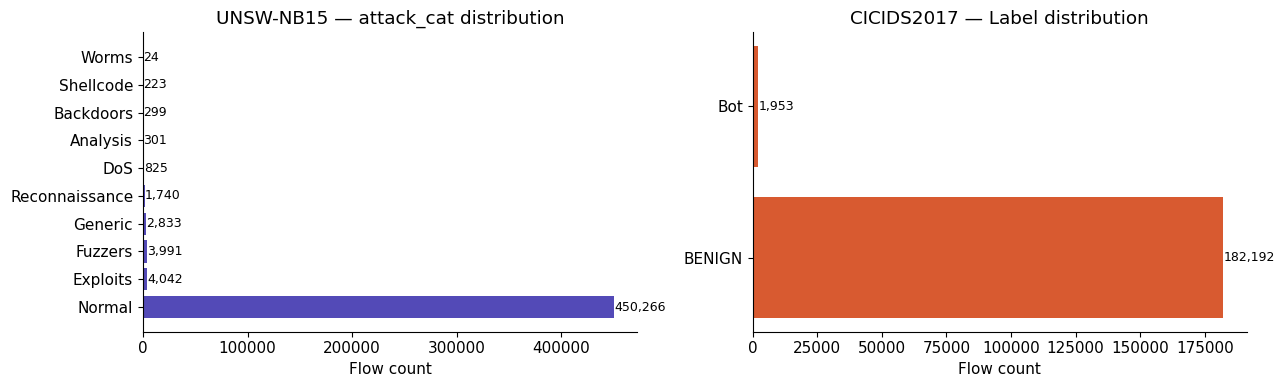

Saved: eda_01_class_balance.png


In [7]:
# 4a. Class balance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

unsw_counts = unsw_df['attack_cat'].value_counts()
axes[0].barh(unsw_counts.index, unsw_counts.values, color=PALETTE[0])
axes[0].set_title('UNSW-NB15 — attack_cat distribution')
axes[0].set_xlabel('Flow count')
for i, v in enumerate(unsw_counts.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

cic_counts = cicid_df['Label'].value_counts()
axes[1].barh(cic_counts.index, cic_counts.values, color=PALETTE[2])
axes[1].set_title('CICIDS2017 — Label distribution')
axes[1].set_xlabel('Flow count')
for i, v in enumerate(cic_counts.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_01_class_balance.png')

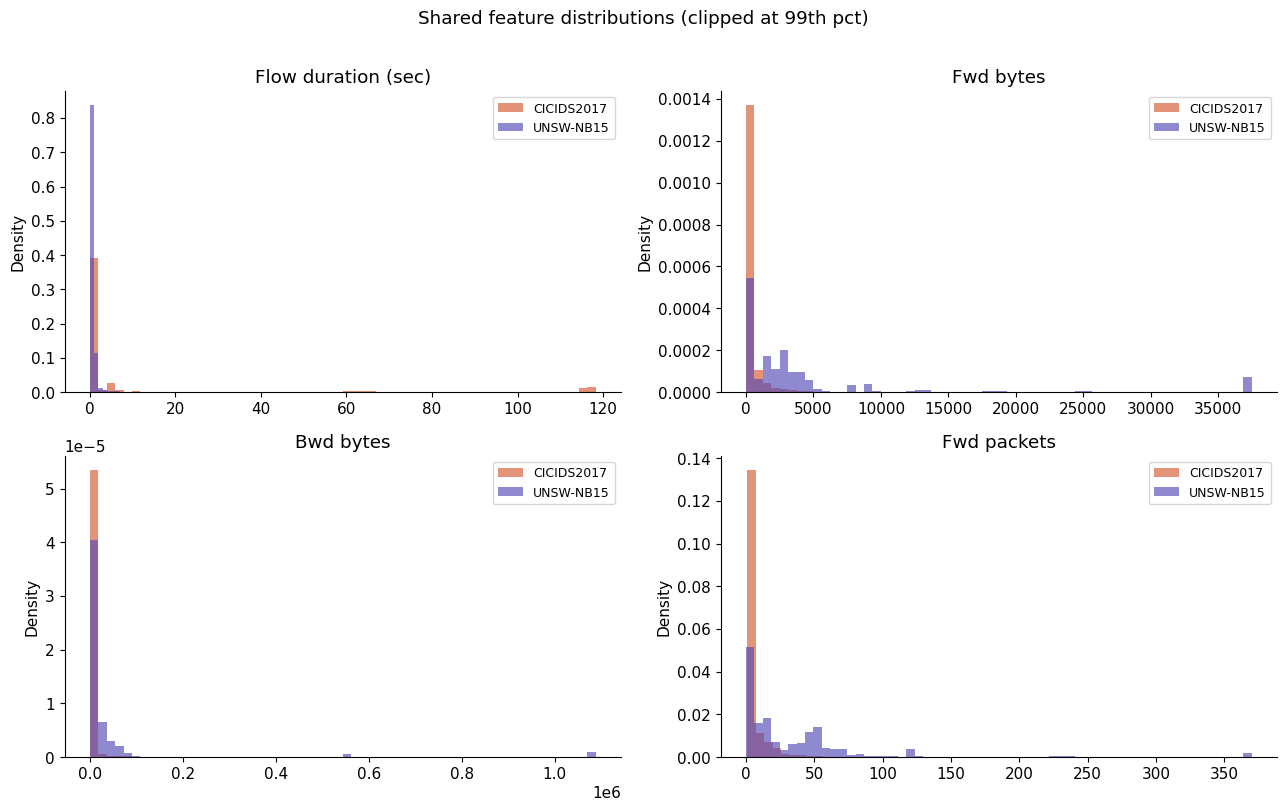

Saved: eda_02_shared_distributions.png


In [8]:
# 4b. Shared numeric distributions
shared_plot = {
    'Flow duration (sec)' : (cicid_df['Flow Duration'] / 1e6,  unsw_df['dur']),
    'Fwd bytes'           : (cicid_df['Total Length of Fwd Packets'], unsw_df['sbytes']),
    'Bwd bytes'           : (cicid_df['Total Length of Bwd Packets'], unsw_df['dbytes']),
    'Fwd packets'         : (cicid_df['Total Fwd Packets'],  unsw_df['Spkts']),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (title, (cic_col, unsw_col)) in zip(axes, shared_plot.items()):
    cic_vals  = cic_col.dropna()
    unsw_vals = unsw_col.dropna()
    cap = max(np.percentile(cic_vals, 99), np.percentile(unsw_vals, 99))
    ax.hist(cic_vals.clip(upper=cap),  bins=60, alpha=0.65, color=PALETTE[2], label='CICIDS2017', density=True)
    ax.hist(unsw_vals.clip(upper=cap), bins=60, alpha=0.65, color=PALETTE[0], label='UNSW-NB15',  density=True)
    ax.set_title(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Shared feature distributions (clipped at 99th pct)', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_shared_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_02_shared_distributions.png')

---
## 5. Build Unified Dataset (Integration)

In [9]:
# STEP 1 — Rename to unified column names
unsw_rename = {
    'dsport'  : 'dst_port',
    'dur'     : 'flow_duration_sec',
    'Spkts'   : 'total_fwd_pkts',
    'Dpkts'   : 'total_bwd_pkts',
    'sbytes'  : 'fwd_bytes',
    'dbytes'  : 'bwd_bytes',
    'smeansz' : 'fwd_pkt_mean_size',
    'dmeansz' : 'bwd_pkt_mean_size',
    'swin'    : 'init_win_fwd',
    'dwin'    : 'init_win_bwd',
    'Sintpkt' : 'fwd_iat_mean_ms',
    'Dintpkt' : 'bwd_iat_mean_ms',
    'srcip'   : 'src_ip',
    'dstip'   : 'dst_ip',
}
unsw = unsw_df.rename(columns=unsw_rename).copy()

cicid_rename = {
    'Destination Port'               : 'dst_port',
    'Total Fwd Packets'              : 'total_fwd_pkts',
    'Total Backward Packets'         : 'total_bwd_pkts',
    'Total Length of Fwd Packets'    : 'fwd_bytes',
    'Total Length of Bwd Packets'    : 'bwd_bytes',
    'Fwd Packet Length Mean'         : 'fwd_pkt_mean_size',
    'Bwd Packet Length Mean'         : 'bwd_pkt_mean_size',
    'Init_Win_bytes_forward'         : 'init_win_fwd',
    'Init_Win_bytes_backward'        : 'init_win_bwd',
}
cicid = cicid_df.rename(columns=cicid_rename).copy()

# Unit conversions
cicid['flow_duration_sec'] = cicid['Flow Duration'] / 1e6
cicid['fwd_iat_mean_ms']   = cicid['Fwd IAT Mean']  / 1e3
cicid['bwd_iat_mean_ms']   = cicid['Bwd IAT Mean']  / 1e3

# CICIDS has no real IP columns — we'll simulate them in Section 7
cicid['src_ip'] = np.nan
cicid['dst_ip'] = np.nan

print('Step 1 complete: direct renames done.')

Step 1 complete: direct renames done.


In [10]:
# STEP 2 — Derived features

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

for df in [unsw, cicid]:
    total_pkts  = df['total_fwd_pkts'] + df['total_bwd_pkts']
    total_bytes = df['fwd_bytes'] + df['bwd_bytes']
    dur = df['flow_duration_sec']

    df['flow_pkts_per_sec']  = safe_divide(total_pkts,           dur)
    df['fwd_pkts_per_sec']   = safe_divide(df['total_fwd_pkts'], dur)
    df['bwd_pkts_per_sec']   = safe_divide(df['total_bwd_pkts'], dur)
    df['down_up_ratio']      = safe_divide(df['total_bwd_pkts'], df['total_fwd_pkts'])
    df['avg_pkt_size']       = safe_divide(total_bytes, total_pkts)

cicid['flow_bytes_per_sec'] = cicid['Flow Bytes/s']
unsw['flow_bytes_per_sec']  = (unsw['Sload'] + unsw['Dload']) / 8

print('Step 2 complete: derived features computed.')

Step 2 complete: derived features computed.


In [11]:
# STEP 3 — Enrichment columns

def derive_service(port_series):
    port_map = {80:'http',443:'https',53:'dns',22:'ssh',
                21:'ftp',25:'smtp',110:'pop3',143:'imap',
                3306:'mysql',8080:'http-alt'}
    return port_series.map(lambda p: port_map.get(int(p),'other') if pd.notna(p) else 'unknown')

def derive_protocol_from_port(port_series):
    udp_ports = {53,67,68,69,123,161,162,514}
    return port_series.map(lambda p: 'udp' if pd.notna(p) and int(p) in udp_ports else 'tcp')

def derive_conn_state_from_flags(df):
    state = pd.Series('CON', index=df.index)
    if 'SYN Flag Count' in df.columns:
        has_syn = df['SYN Flag Count'].fillna(0) > 0
        has_fin = df['FIN Flag Count'].fillna(0) > 0
        has_rst = df['RST Flag Count'].fillna(0) > 0
        state = np.where(has_rst, 'RST',
                np.where(has_syn & has_fin, 'FIN',
                np.where(has_syn, 'INT', 'CON')))
    return pd.Series(state, index=df.index)

unsw['service']        = unsw['service'].fillna('other').str.strip()
unsw['protocol']       = unsw['proto'].fillna('tcp').str.lower()
unsw['conn_state']     = unsw['state'].fillna('CON').str.upper()
unsw['source_dataset'] = 'UNSW-NB15'

cicid['service']        = derive_service(cicid['dst_port'])
cicid['protocol']       = derive_protocol_from_port(cicid['dst_port'])
cicid['conn_state']     = derive_conn_state_from_flags(cicid_df)
cicid['source_dataset'] = 'CICIDS2017'

print('Step 3 complete: enrichment columns generated.')

Step 3 complete: enrichment columns generated.


In [12]:
# STEP 4 — Unified attack label taxonomy

LABEL_MAP_CICIDS = {
    'BENIGN'                          : ('Normal',         0),
    'DoS Hulk'                        : ('DoS',            1),
    'DoS GoldenEye'                   : ('DoS',            1),
    'DoS slowloris'                   : ('DoS',            1),
    'DoS Slowhttptest'                : ('DoS',            1),
    'Heartbleed'                      : ('DoS',            1),
    'DDoS'                            : ('DDoS',           1),
    'PortScan'                        : ('Reconnaissance', 1),
    'FTP-Patator'                     : ('Brute Force',    1),
    'SSH-Patator'                     : ('Brute Force',    1),
    'Bot'                             : ('Malware',        1),
    'Web Attack \x96 XSS'             : ('Web Attack',     1),
    'Web Attack \x96 Sql Injection'   : ('Web Attack',     1),
    'Web Attack \x96 Brute Force'     : ('Web Attack',     1),
    'Infiltration'                    : ('Infiltration',   1),
}

LABEL_MAP_UNSW = {
    'Normal'        : ('Normal',         0),
    'DoS'           : ('DoS',            1),
    'Reconnaissance': ('Reconnaissance', 1),
    'Backdoors'     : ('Malware',        1),
    'Worms'         : ('Malware',        1),
    'Fuzzers'       : ('Web Attack',     1),
    'Generic'       : ('Web Attack',     1),
    'Exploits'      : ('Brute Force',    1),
    'Shellcode'     : ('Infiltration',   1),
    'Analysis'      : ('Infiltration',   1),
}

def apply_label_map(raw_label, label_map, default=('Unknown', 1)):
    return label_map.get(str(raw_label).strip(), default)

cicid[['attack_family','binary_label']] = cicid['Label'].apply(
    lambda x: pd.Series(apply_label_map(x, LABEL_MAP_CICIDS)))
unsw[['attack_family','binary_label']] = unsw['attack_cat'].apply(
    lambda x: pd.Series(apply_label_map(x, LABEL_MAP_UNSW)))

cicid['attack_label_raw'] = cicid['Label']
unsw['attack_label_raw']  = unsw['attack_cat']

print('Step 4 complete: labels unified.')
print('\nUnified attack_family distribution:')
print(pd.concat([cicid[['attack_family','source_dataset']],
                 unsw[['attack_family','source_dataset']]]).groupby(
    ['source_dataset','attack_family']).size().unstack(fill_value=0))

Step 4 complete: labels unified.

Unified attack_family distribution:
attack_family   Brute Force  DoS  Infiltration  Malware  Normal  \
source_dataset                                                    
CICIDS2017                0    0             0     1953  182192   
UNSW-NB15              4042  825           524      323  450266   

attack_family   Reconnaissance  Web Attack  
source_dataset                              
CICIDS2017                   0           0  
UNSW-NB15                 1740        6824  


In [13]:
# STEP 5 — Select unified columns and concat

UNIFIED_COLS = [
    'source_dataset', 'capture_timestamp',
    'src_ip', 'dst_ip',
    'dst_port', 'flow_duration_sec',
    'total_fwd_pkts', 'total_bwd_pkts',
    'fwd_bytes', 'bwd_bytes',
    'fwd_pkt_mean_size', 'bwd_pkt_mean_size',
    'init_win_fwd', 'init_win_bwd',
    'flow_bytes_per_sec', 'flow_pkts_per_sec',
    'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
    'down_up_ratio', 'avg_pkt_size',
    'fwd_iat_mean_ms', 'bwd_iat_mean_ms',
    'service', 'protocol', 'conn_state',
    'attack_label_raw', 'attack_family', 'binary_label',
]

unified_df = pd.concat(
    [cicid[UNIFIED_COLS], unsw[UNIFIED_COLS]],
    ignore_index=True
)
unified_df.insert(0, 'flow_id', range(1, len(unified_df) + 1))

print(f'Unified dataset shape   : {unified_df.shape}')
print(f'  CICIDS rows           : {len(cicid):,}')
print(f'  UNSW rows             : {len(unsw):,}')
print(f'  Total                 : {len(unified_df):,}')
print(f'\nNull capture_timestamp  : {unified_df["capture_timestamp"].isnull().sum()}')

Unified dataset shape   : (648689, 29)
  CICIDS rows           : 184,145
  UNSW rows             : 464,544
  Total                 : 648,689

Null capture_timestamp  : 1


---
## 6. EDA on Unified Dataset

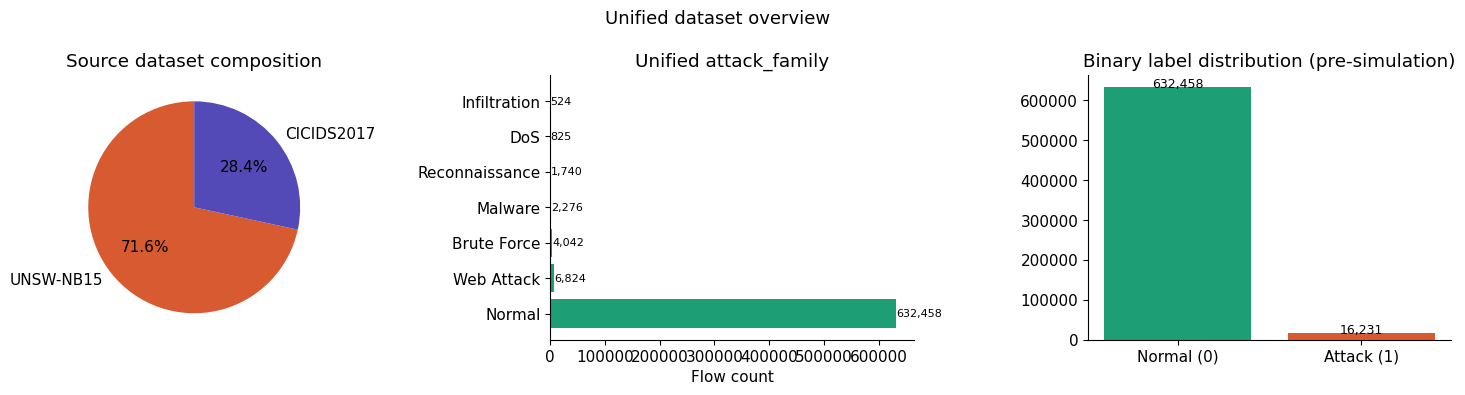

Saved: eda_07_unified_overview.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

src = unified_df['source_dataset'].value_counts()
axes[0].pie(src.values, labels=src.index, autopct='%1.1f%%',
            colors=[PALETTE[2], PALETTE[0]], startangle=90)
axes[0].set_title('Source dataset composition')

fam = unified_df['attack_family'].value_counts()
axes[1].barh(fam.index, fam.values, color=PALETTE[1])
axes[1].set_title('Unified attack_family')
axes[1].set_xlabel('Flow count')
for i, v in enumerate(fam.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

bl = unified_df['binary_label'].value_counts().sort_index()
axes[2].bar(['Normal (0)', 'Attack (1)'], bl.values,
            color=[PALETTE[1], PALETTE[2]])
axes[2].set_title('Binary label distribution (pre-simulation)')
for i, v in enumerate(bl.values):
    axes[2].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Unified dataset overview', fontsize=13)
plt.tight_layout()
plt.savefig('eda_07_unified_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_07_unified_overview.png')

---
## 7. Data Simulation Layer

**Why simulate?** You are testing the pipeline with only 1 CICIDS file + 1 UNSW file.
The issues below prevent a meaningful DWH without simulation:

| Problem | Impact | Simulation fix |
|---------|--------|----------------|
| CICIDS timestamps all `2017-07-07` | `dim_time` collapses to 1 CICIDS row | Spread across 7 days × 24 hours |
| Only BENIGN in CICIDS | `dim_attack_label` has no CICIDS attack rows | Add 3K synthetic attack flows |
| Only 2 capture sessions | `dim_capture_session` trivial | Add 3 synthetic sessions |
| CICIDS has no IP columns | Can't build `dim_endpoint` with geo | Simulate IP ranges |

> Once you add all 8 CICIDS files + all UNSW files, you can set `SIMULATE = False` and skip this section entirely.

In [15]:
SIMULATE = True        # Set to False when you load all real files
SYNTH_ATTACK_ROWS = 3_000
np.random.seed(42)

if SIMULATE:
    print('=== SIMULATION MODE ON ===')

    # ── 7a. Spread CICIDS timestamps across 7 days × 24 hours ────────────
    cicid_mask = unified_df['source_dataset'] == 'CICIDS2017'
    n_cicid = cicid_mask.sum()
    base_dates = pd.date_range('2017-07-03', '2017-07-07', freq='D')   # Mon–Fri
    random_dates  = np.random.choice(base_dates, size=n_cicid)
    random_hours  = np.random.randint(7, 19, size=n_cicid)             # working hours
    random_mins   = np.random.randint(0, 60, size=n_cicid)
    simulated_ts  = pd.to_datetime(random_dates) + \
                    pd.to_timedelta(random_hours, unit='h') + \
                    pd.to_timedelta(random_mins, unit='m')
    unified_df.loc[cicid_mask, 'capture_timestamp'] = simulated_ts
    print(f'  Timestamps spread: {unified_df.loc[cicid_mask,"capture_timestamp"].dt.date.nunique()} unique days for CICIDS')

    # ── 7b. Simulate IP columns ───────────────────────────────────────────
    # UNSW already has real IPs.  CICIDS gets plausible RFC1918 ranges.
    def rand_ip(prefix):
        return f"{prefix}.{np.random.randint(1,255)}.{np.random.randint(1,255)}"

    cicid_idx = unified_df[cicid_mask].index
    unified_df.loc[cicid_idx, 'src_ip'] = [
        rand_ip('192.168.1') for _ in range(n_cicid)]
    unified_df.loc[cicid_idx, 'dst_ip'] = [
        rand_ip('10.0.0') for _ in range(n_cicid)]
    print(f'  IP columns simulated for {n_cicid:,} CICIDS rows')

    # ── 7c. Synthetic attack flows (all 8 families) ───────────────────────
    ATTACK_FAMILIES = ['DoS','DDoS','Reconnaissance','Brute Force',
                       'Malware','Web Attack','Infiltration','Unknown']
    PROTOCOLS       = ['tcp','udp','icmp']
    CONN_STATES     = ['CON','FIN','RST','INT']
    SERVICES        = ['http','https','dns','ssh','ftp','smtp','other']

    rows_per_family = SYNTH_ATTACK_ROWS // len(ATTACK_FAMILIES)
    synth_rows = []

    for family in ATTACK_FAMILIES:
        n = rows_per_family
        dur = np.random.exponential(0.5, n).clip(0.001)
        fwd_pkts  = np.random.randint(1, 500, n).astype(float)
        bwd_pkts  = np.random.randint(0, 200, n).astype(float)
        fwd_bytes = (fwd_pkts * np.random.uniform(40, 1500, n)).astype(float)
        bwd_bytes = (bwd_pkts * np.random.uniform(0,  1500, n)).astype(float)
        ports     = np.random.choice([80,443,22,21,53,3306,8080,0], n)

        src_ips = [rand_ip('172.16.0') for _ in range(n)]
        dst_ips = [rand_ip('10.0.1') for _ in range(n)]

        ts_dates = np.random.choice(base_dates, n)
        ts_hours = np.random.randint(0, 24, n)
        ts = pd.to_datetime(ts_dates) + pd.to_timedelta(ts_hours, unit='h')

        total_pkts  = fwd_pkts + bwd_pkts
        total_bytes = fwd_bytes + bwd_bytes

        df_synth = pd.DataFrame({
            'source_dataset'  : 'SYNTHETIC',
            'capture_timestamp': ts,
            'src_ip'          : src_ips,
            'dst_ip'          : dst_ips,
            'dst_port'        : ports.astype(float),
            'flow_duration_sec': dur,
            'total_fwd_pkts'  : fwd_pkts,
            'total_bwd_pkts'  : bwd_pkts,
            'fwd_bytes'       : fwd_bytes,
            'bwd_bytes'       : bwd_bytes,
            'fwd_pkt_mean_size': fwd_bytes / fwd_pkts.clip(1),
            'bwd_pkt_mean_size': np.where(bwd_pkts>0, bwd_bytes/bwd_pkts.clip(1), 0),
            'init_win_fwd'    : np.random.choice([64,256,512,1024,8192,65535], n).astype(float),
            'init_win_bwd'    : np.random.choice([64,256,512,1024,8192,65535], n).astype(float),
            'flow_bytes_per_sec': total_bytes / dur,
            'flow_pkts_per_sec' : total_pkts  / dur,
            'fwd_pkts_per_sec'  : fwd_pkts    / dur,
            'bwd_pkts_per_sec'  : bwd_pkts    / dur,
            'down_up_ratio'     : bwd_pkts    / fwd_pkts.clip(1),
            'avg_pkt_size'      : total_bytes / total_pkts.clip(1),
            'fwd_iat_mean_ms'   : np.random.exponential(50, n),
            'bwd_iat_mean_ms'   : np.random.exponential(80, n),
            'service'           : np.random.choice(SERVICES, n),
            'protocol'          : np.random.choice(PROTOCOLS, n),
            'conn_state'        : np.random.choice(CONN_STATES, n),
            'attack_label_raw'  : family,
            'attack_family'     : family,
            'binary_label'      : 1,
        })
        synth_rows.append(df_synth)

    synth_df = pd.concat(synth_rows, ignore_index=True)
    unified_df = pd.concat([unified_df, synth_df], ignore_index=True)
    unified_df['flow_id'] = range(1, len(unified_df) + 1)   # re-sequence
    print(f'  Synthetic attack rows added : {len(synth_df):,}')
    print(f'  Unified shape after simulation: {unified_df.shape}')

else:
    print('SIMULATE=False — skipping simulation, using real data only.')

=== SIMULATION MODE ON ===
  Timestamps spread: 5 unique days for CICIDS
  IP columns simulated for 184,145 CICIDS rows
  Synthetic attack rows added : 3,000
  Unified shape after simulation: (651689, 29)


---
## 8. Build DWH Star Schema Tables

### PK/FK Strategy

Each dimension table gets a **surrogate integer PK** generated with `range(1, n+1)`.
The PK is joined back to `unified_df` as a FK column **before** the fact table is extracted.
This guarantees every fact row has a valid FK — no nulls.

```
dim_X  ──[deduplicate on natural keys]──> assign PK (x_key)
                                              │
unified_df ──[merge on natural keys]──> x_key column added
                                              │
fact_network_flow ──[select FK columns]──> x_key as FK
```

In [19]:
# ── FIX: Drop the 1 null-timestamp row before dim_time build ─────────────
ts_nulls = unified_df['capture_timestamp'].isnull().sum()
if ts_nulls > 0:
    unified_df = unified_df.dropna(subset=['capture_timestamp']).copy()
    print(f'Dropped {ts_nulls} row(s) with null capture_timestamp')

# ── dim_time ─────────────────────────────────────────────────────────────

ts = unified_df['capture_timestamp']

dim_time_raw = pd.DataFrame({
    'year'              : ts.dt.year,
    'month'             : ts.dt.month,
    'day'               : ts.dt.day,
    'hour'              : ts.dt.hour,
    'day_of_week'       : ts.dt.day_name(),
    'week'              : ts.dt.isocalendar().week.astype(int),
    'is_business_hours' : ts.dt.hour.between(9, 17).astype(int),
    'is_weekend'        : ts.dt.dayofweek.isin([5, 6]).astype(int),
})

# Better time buckets
conditions = [
    dim_time_raw['hour'].between(0, 5),
    dim_time_raw['hour'].between(6, 11),
    dim_time_raw['hour'].between(12, 16),
    dim_time_raw['hour'].between(17, 20),
    dim_time_raw['hour'].between(21, 23)
]

choices = [
    'Night',
    'Morning',
    'Afternoon',
    'Evening',
    'Night'
]

dim_time_raw['time_bucket'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

# FIXED granularity
dim_time = (
    dim_time_raw
    .drop_duplicates(
        subset=['year','month','day','hour']
    )
    .reset_index(drop=True)
)

dim_time.insert(0, 'time_key', range(1, len(dim_time)+1))

# Rebuild mapping
time_lookup = dim_time.merge(
    dim_time_raw,
    on=['year','month','day','hour',
        'day_of_week','week',
        'is_business_hours',
        'is_weekend',
        'time_bucket'],
    how='left'
)

unified_df = unified_df.reset_index(drop=True)
unified_df['time_key'] = time_lookup['time_key']

In [35]:
# Drop any stale keys from previous runs before re-merging
cols_to_drop = [c for c in unified_df.columns if c in ['endpoint_key', 'service_key']]
unified_df = unified_df.drop(columns=cols_to_drop)

# Now merge cleanly
unified_df = unified_df.merge(dim_service, on='service', how='left')
unified_df = unified_df.merge(dim_endpoint, on='dst_port', how='left')

In [36]:
print(f"Rows: {len(unified_df)}")
print(f"Null endpoint_keys: {unified_df['endpoint_key'].isna().sum()}")
print(f"Null service_keys:  {unified_df['service_key'].isna().sum()}")

Rows: 651688
Null endpoint_keys: 0
Null service_keys:  0


In [41]:
# Before merging, drop any existing foreign key columns from unified_df,
# including potential suffixed versions from previous failed merges or reruns.
# This ensures a clean merge for the newly generated keys.
cols_to_drop_from_unified = [
    'endpoint_key', 'endpoint_key_x', 'endpoint_key_y',
    'service_key', 'service_key_x', 'service_key_y'
]
# Use errors='ignore' so it doesn't fail if a column isn't present
unified_df = unified_df.drop(columns=[col for col in cols_to_drop_from_unified if col in unified_df.columns], errors='ignore')


# dim_endpoint: port attributes only
dim_endpoint = (
    unified_df[['dst_port']]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_endpoint.insert(0, 'endpoint_key', range(1, len(dim_endpoint) + 1))

dim_endpoint['port_range_label'] = pd.cut(
    dim_endpoint['dst_port'].fillna(-1),
    bins=[-2, 0, 1023, 49151, 65535],
    labels=['invalid', 'well-known', 'registered', 'ephemeral']
).astype(str)

dim_endpoint['is_well_known_port'] = (dim_endpoint['dst_port'] < 1024).astype(int)
dim_endpoint['is_valid_port'] = unified_df['dst_port'].notna() & (unified_df['dst_port'] >= 0)

# dim_service: application-layer service, separate dimension
dim_service = (
    unified_df[['service']]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_service.insert(0, 'service_key', range(1, len(dim_service) + 1))

# Then add service_key FK to unified_df / fact table
# With the previous drop, these merges should now be clean and not require suffixes
unified_df = unified_df.merge(dim_service, on='service', how='left')
unified_df = unified_df.merge(dim_endpoint, on='dst_port', how='left')

In [33]:
# Step 2: resolve by keeping the most frequent label per port
# (or hardcode a priority: CICIDS > UNSW)
service_map = (
    unified_df.groupby(['dst_port', 'service'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates(subset=['dst_port'], keep='first')
    [['dst_port', 'service']]
)

# Step 3: rebuild dim_endpoint using the resolved map
dim_endpoint = (
    unified_df[['dst_port']]
    .drop_duplicates()
    .merge(service_map, on='dst_port', how='left')
    .reset_index(drop=True)
)

dim_endpoint.insert(0, 'endpoint_key', range(1, len(dim_endpoint) + 1))

In [23]:
## ── dim_protocol_flag ────────────────────────────────────────────────────

# Remove old protocol_key if rerunning notebook
unified_df = unified_df.drop(
    columns=['protocol_key'],
    errors='ignore'
)

dim_protocol = (
    unified_df[['protocol', 'conn_state']]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_protocol.insert(
    0,
    'protocol_key',
    range(1, len(dim_protocol) + 1)
)

dim_protocol['flag_combo_label'] = (
    dim_protocol['protocol'].str.upper()
    + '-'
    + dim_protocol['conn_state']
)

# FIXED handshake logic
dim_protocol['is_handshake'] = (
    dim_protocol['conn_state'] == 'INT'
).astype(int)

dim_protocol['is_teardown'] = (
    dim_protocol['conn_state'].isin(['FIN', 'RST'])
).astype(int)

# Merge FULL dimension table
unified_df = unified_df.merge(
    dim_protocol,
    on=['protocol', 'conn_state'],
    how='left'
)

print(f'dim_protocol_flag shape : {dim_protocol.shape}')
print(f'protocol_key nulls      : {unified_df["protocol_key"].isnull().sum()}')

dim_protocol.head()

dim_protocol_flag shape : (160, 6)
protocol_key nulls      : 0


,protocol_key,protocol,conn_state,flag_combo_label,is_handshake,is_teardown
0,1,tcp,INT,TCP-INT,1,0
1,2,tcp,CON,TCP-CON,0,0
2,3,udp,CON,UDP-CON,0,0
3,4,tcp,RST,TCP-RST,0,1
4,5,arp,INT,ARP-INT,1,0


In [55]:
# ── dim_attack_label ─────────────────────────────────────────────────────
SEVERITY = {
    'Normal':0,'Reconnaissance':1,'Web Attack':2,'Brute Force':2,
    'DoS':3,'DDoS':3,'Malware':4,'Infiltration':4,'Unknown':1
}

# Drop stale keys
cols_to_drop_from_unified_attack = ['label_key', 'label_key_x', 'label_key_y']
unified_df = unified_df.drop(columns=[col for col in cols_to_drop_from_unified_attack if col in unified_df.columns], errors='ignore')

# Standardize BENIGN → Normal so both datasets share one label
unified_df['attack_label_raw'] = unified_df['attack_label_raw'].replace({'BENIGN': 'Normal'})

# Remove source_dataset — attack taxonomy should be dataset-agnostic
dim_attack = (
    unified_df[['attack_label_raw', 'attack_family', 'binary_label']]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_attack.insert(0, 'label_key', range(1, len(dim_attack)+1))
dim_attack['severity_tier'] = dim_attack['attack_family'].map(SEVERITY).fillna(1).astype(int)

# Merge on attack semantics only
unified_df = unified_df.merge(
    dim_attack[['label_key', 'attack_label_raw', 'attack_family']],
    on=['attack_label_raw', 'attack_family'],
    how='left'
)

print(f'dim_attack_label shape  : {dim_attack.shape}')  # expect 17
print(f'label_key nulls         : {unified_df["label_key"].isnull().sum()}')  # expect 0
dim_attack

dim_attack_label shape  : (17, 5)
label_key nulls         : 0


,label_key,attack_label_raw,attack_family,binary_label,severity_tier
0,1,Normal,Normal,0,0
1,2,Bot,Malware,1,4
2,3,Exploits,Brute Force,1,2
3,4,Reconnaissance,Reconnaissance,1,1
4,5,DoS,DoS,1,3
5,6,Generic,Web Attack,1,2
6,7,Shellcode,Infiltration,1,4
7,8,Fuzzers,Web Attack,1,2
8,9,Worms,Malware,1,4
9,10,Backdoors,Malware,1,4


In [51]:
# ── dim_capture_session ──────────────────────────────────────────────────
# Real sessions from actual datasets + 3 synthetic sessions (when SIMULATE=True)

session_meta = {
    'CICIDS2017': {
        'session_name'       : 'CICIDS2017 Full Week',
        'collection_tool'    : 'CICFlowMeter',
        'network_scenario'   : 'Enterprise network traffic',
        'has_bulk_features'  : 1,
        'has_iat_std'        : 1,
        'data_quality_flag'  : 'cleaned_and_integrated',
    },
    'UNSW-NB15': {
        'session_name'       : 'UNSW-NB15 Mixed Traffic',
        'collection_tool'    : 'Argus/Bro-IDS',
        'network_scenario'   : 'Synthetic attack traffic',
        'has_bulk_features'  : 0,
        'has_iat_std'        : 0,
        'data_quality_flag'  : 'cleaned_and_integrated',
    },

    'SYNTHETIC': {
        'session_name'       : 'Simulated Pipeline Test',
        'collection_tool'    : 'Simulation',
        'network_scenario'   : 'Synthetic attack flows for DWH testing',
        'has_bulk_features'  : 1,
        'has_iat_std'        : 1,
        'data_quality_flag'  : 'simulated_data',
    },
}

# Only include sessions that actually appear in the data
present_sources = unified_df['source_dataset'].unique()
session_meta_filtered = {k:v for k,v in session_meta.items() if k in present_sources}

dim_session = pd.DataFrame.from_dict(session_meta_filtered, orient='index').reset_index()
dim_session.rename(columns={'index':'source_dataset'}, inplace=True)
dim_session.insert(0, 'session_key', range(1, len(dim_session)+1))

# --- ADDED: Drop existing session_key columns to prevent merge conflicts ---
cols_to_drop_from_unified_session = [
    'session_key', 'session_key_x', 'session_key_y'
]
unified_df = unified_df.drop(columns=[col for col in cols_to_drop_from_unified_session if col in unified_df.columns], errors='ignore')
# ---------------------------------------------------------------------------

unified_df = unified_df.merge(
    dim_session[['session_key','source_dataset']],
    on='source_dataset', how='left'
)
print(f'dim_capture_session shape: {dim_session.shape}')
print(f'session_key nulls         : {unified_df["session_key"].isnull().sum()}')
dim_session

dim_capture_session shape: (3, 8)
session_key nulls         : 0


,session_key,source_dataset,session_name,collection_tool,network_scenario,has_bulk_features,has_iat_std,data_quality_flag
0,1,CICIDS2017,CICIDS2017 Full Week,CICFlowMeter,Enterprise network traffic,1,1,cleaned_and_integrated
1,2,UNSW-NB15,UNSW-NB15 Mixed Traffic,Argus/Bro-IDS,Synthetic attack traffic,0,0,cleaned_and_integrated
2,3,SYNTHETIC,Simulated Pipeline Test,Simulation,Synthetic attack flows for DWH testing,1,1,simulated_data


In [56]:
FACT_COLS = [
    'flow_id',

    # Foreign Keys
    'time_key',
    'endpoint_key',
    'service_key',
    'protocol_key',
    'label_key',
    'session_key',

    # Core Measures
    'flow_duration_sec',
    'flow_pkts_per_sec',
    'flow_bytes_per_sec',

    # New Derived Measures
    'total_bytes',
    'iat_asymmetry',
    'large_pkt_flag',
]

fact_network_flow = unified_df[FACT_COLS].copy()

# Verify
print(f'fact_network_flow shape : {fact_network_flow.shape}')
fk_null_check = fact_network_flow[['time_key','endpoint_key','service_key',
                                    'protocol_key','label_key','session_key']].isnull().sum()
print('FK null check:')
print(fk_null_check)

fact_network_flow.to_csv('fact_network_flow.csv', index=False)
print("Saved.")

fact_network_flow shape : (651688, 13)
FK null check:
time_key        0
endpoint_key    0
service_key     0
protocol_key    0
label_key       0
session_key     0
dtype: int64
Saved.


In [57]:
dim_attack.to_csv('dim_attack_Label.csv', index=False)
# fact_network_flow is already created in the previous cell, no need to recreate.
# fact_network_flow = unified_df[FACT_COLS].copy()
fact_network_flow.to_csv('Fact_Network_flow.csv', index=False)

In [54]:
fact_network_flow.to_csv('Fact_Network_Flow.csv', index=False)

---
## 9. PK/FK Integrity Assertion
Fails loudly if any FK column has nulls — catches integration bugs before export.

In [27]:
FK_COLS = ['time_key','endpoint_key','protocol_key','label_key','session_key']
fk_nulls = fact_network_flow[FK_COLS].isnull().sum()

assert fk_nulls.sum() == 0, (
    f"FK integrity FAILED — null FKs detected:\n{fk_nulls[fk_nulls > 0]}"
)
print('✅ All FK columns are non-null — PK/FK integrity passed.')

# Also verify all PKs in dims are referenced
for fk_col, dim, pk_col in [
    ('time_key',     dim_time,     'time_key'),
    ('endpoint_key', dim_endpoint, 'endpoint_key'),
    ('protocol_key', dim_protocol, 'protocol_key'),
    ('label_key',    dim_attack,   'label_key'),
    ('session_key',  dim_session,  'session_key'),
]:
    orphan_fks = set(fact_network_flow[fk_col].dropna()) - set(dim[pk_col])
    assert len(orphan_fks) == 0, f'Orphan FKs in {fk_col}: {orphan_fks}'
print('✅ All FK values exist in their respective dimension PKs.')

✅ All FK columns are non-null — PK/FK integrity passed.
✅ All FK values exist in their respective dimension PKs.


---
## 10. Export for Power BI

In [31]:
tables = {
    'fact_network_flow'   : fact_network_flow,
    'dim_time'            : dim_time,
    'dim_endpoint'        : dim_endpoint,
    'dim_protocol_flag'   : dim_protocol,
    'dim_attack_label'    : dim_attack,
    'dim_capture_session' : dim_session,
    'dim_service'         : dim_service,
}

for name, df in tables.items():
    path = f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Exported {path:35s}  shape={df.shape}')

print('\n── Power BI import instructions ────────────────────────────────────')
print('1. Home > Get Data > Text/CSV  → import each CSV')
print('2. Model view: create relationships (Many-to-One, cross-filter = Single)')
print('   fact_network_flow[time_key]     → dim_time[time_key]')
print('   fact_network_flow[endpoint_key] → dim_endpoint[endpoint_key]')
print('   fact_network_flow[protocol_key] → dim_protocol_flag[protocol_key]')
print('   fact_network_flow[label_key]    → dim_attack_label[label_key]')
print('   fact_network_flow[session_key]  → dim_capture_session[session_key]')
print('   fact_network_flow[service_key]  → dim_service[service_key]')
print('3. Mark dim_time as Date Table on capture_timestamp')

Exported fact_network_flow.csv                shape=(651688, 12)

── Power BI import instructions ────────────────────────────────────
1. Home > Get Data > Text/CSV  → import each CSV
2. Model view: create relationships (Many-to-One, cross-filter = Single)
   fact_network_flow[time_key]     → dim_time[time_key]
   fact_network_flow[endpoint_key] → dim_endpoint[endpoint_key]
   fact_network_flow[protocol_key] → dim_protocol_flag[protocol_key]
   fact_network_flow[label_key]    → dim_attack_label[label_key]
   fact_network_flow[session_key]  → dim_capture_session[session_key]
3. Mark dim_time as Date Table on capture_timestamp


In [29]:
for name, df in tables.items():
    print(f'\n{name}')
    print(df.dtypes)


fact_network_flow
flow_id                 int64
time_key                int64
endpoint_key            int64
protocol_key            int64
label_key               int64
session_key             int64
flow_duration_sec     float64
flow_pkts_per_sec     float64
flow_bytes_per_sec    float64
total_bytes           float64
iat_asymmetry         float64
large_pkt_flag          int64
dtype: object

dim_time
time_key              int64
year                  int32
month                 int32
day                   int32
hour                  int32
day_of_week          object
week                  int64
is_business_hours     int64
is_weekend            int64
time_bucket          object
dtype: object

dim_endpoint
endpoint_key            int64
dst_port              float64
service                object
port_range_label       object
is_well_known_port      int64
dtype: object

dim_protocol_flag
protocol_key         int64
protocol            object
conn_state          object
flag_combo_label    objec

In [ ]:
# ── DAX measures for Power BI ────────────────────────────────────────────
dax = '''
-- Paste these into Power BI DAX editor after loading the tables

Anomaly Rate % =
    DIVIDE(
        COUNTROWS(FILTER(fact_network_flow, fact_network_flow[binary_label] = 1)),
        COUNTROWS(fact_network_flow)
    ) * 100

Avg Flow Bytes per Sec =
    AVERAGEX(
        FILTER(fact_network_flow, NOT ISBLANK(fact_network_flow[flow_bytes_per_sec])),
        fact_network_flow[flow_bytes_per_sec]
    )

Total Attack Flows =
    CALCULATE(
        COUNTROWS(fact_network_flow),
        fact_network_flow[binary_label] = 1
    )

Attack Rate by Family =
    DIVIDE(
        [Total Attack Flows],
        CALCULATE([Total Attack Flows], ALL(dim_attack_label[attack_family]))
    ) * 100

Avg Bytes per Flow =
    AVERAGEX(
        fact_network_flow,
        fact_network_flow[fwd_bytes] + fact_network_flow[bwd_bytes]
    )

High Severity Flows =
    CALCULATE(
        COUNTROWS(fact_network_flow),
        FILTER(dim_attack_label, dim_attack_label[severity_tier] >= 3)
    )
'''
print(dax)

---
## 11. Final Summary

In [ ]:
print('═'*60)
print(' DWH PREPARATION COMPLETE (v2)')
print('═'*60)
for name, df in tables.items():
    print(f'  {name:<30} {df.shape[0]:>8,} rows  {df.shape[1]:>3} cols')
print('-'*60)
total = sum(df.shape[0] for df in tables.values())
print(f'  Total rows across all tables : {total:,}')
print('═'*60)
print()
print('Fixes applied in v2:')
print('  ✅ isocalendar().week NA bug fixed with .fillna(0).astype(int)')
print('  ✅ null capture_timestamp rows dropped before dim_time build')
print('  ✅ CICIDS NaN label row dropped during clean step')
print('  ✅ PK/FK surrogate key strategy: dim PKs joined back as FKs')
print('  ✅ FK integrity assertion — fails loudly if broken')
print('  ✅ Data simulation: timestamps, IPs, synthetic attack flows')
print()
print('When adding all real files:')
print('  → Extend UNSW_FILES and CICIDS_FILES in Section 1')
print('  → Set SIMULATE = False in Section 7')
print('  → Rerun from top — rest of pipeline is file-agnostic')